In [3]:
import numpy as np
import xarray as xr
import sys
sys.path.append('../')
from xdispersion import RelativeDispersion
import matplotlib.cm as cm
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

# Use a serif font globally
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'       # main font for text
mpl.rcParams['mathtext.fontset'] = 'cm'    # math text (e.g., $u_s$)




Compute statistics for all experiments. Take 1m25s on two experiments.

In [4]:

from xdispersion import RelativeDispersion, gen_rbins, rel_disp, rel_diff, kurtosis

# File paths
files = [
    './data/ExpA/fort.3001.np4000nt6000.nc',
    './data/ExpB/fort.1001.np4000nt5993.nc',
    './data/ExpN/fort.1001.np4000nt6000.nc',
    './data/ExpO/fort.1001.np4000nt6000.nc',    
    './data/ExpA/fort.4001nomean.np4000nt6000.nc',
    './data/ExpB/fort.2001nomean.np4000nt5993.nc',
    './data/ExpN/fort.2001nomean.np4000nt6000.nc',
    './data/ExpO/fort.2001nomean.np4000nt6000.nc'
    ]

exp_labels = ["expA", "expB", "expN", "expO","expA fluct", "expB fluct", "expN fluct", "expO fluct"]

# Lists to store results
r2_list, K2_list, Ku_list, rtmp_list = [], [], [], []

for fpath, label in zip(files, exp_labels):
    # Load dataset
    ds = xr.open_dataset(fpath)
    
    # Compute dispersion statistics
    rd = RelativeDispersion(ds, ragged=False, ID='tracer',
                            xpos='x', uvel='ux', time='time',
                            ypos='y', vvel='uy', coord='polar')
    
    pairs = rd.get_all_pairs()
    origin_pairs = rd.get_original_pairs(pairs, r0=[0.005, 0.01])
    rx, ry, rxy, r, rpb = rd.separation_measures(origin_pairs)
    
    r2 = rel_disp(r, order=2, mean_at='const-t')
    K2 = rel_diff(r, mean_at='const-t')
    Ku = kurtosis(r, mean_at='const-t')
    rtmp = np.sqrt(r2)
    
    # Append to lists
    r2_list.append(r2)
    K2_list.append(K2)
    Ku_list.append(Ku)
    rtmp_list.append(rtmp)

/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)
/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)
/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)
/home/dgsl1/miniforge3/envs/xdispersion/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in arccos
  result_data = func(*input_data)


Plot

In [52]:
save=True

#ff682c
#2a0094
#66c2a5
#8da0cb
#ff682c
#2a0094
#66c2a5
#8da0cb


/tmp/ipykernel_32318/3642587943.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(fontsize=8, loc='lower right')


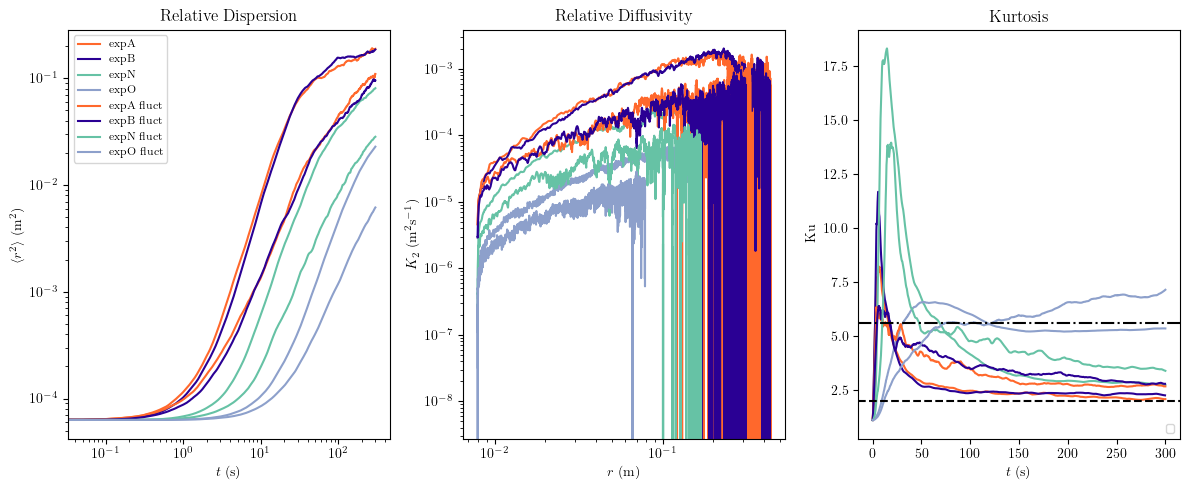

In [ ]:
# Colors (repeated for 8 curves)
colors = ["#ff682c","#2a0094",'#66c2a5', '#8da0cb'] *2

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

for r2, K2, Ku, rtmp, label, c in zip(r2_list, K2_list, Ku_list, rtmp_list, exp_labels, colors):
    linest = '-' if 'nomean' not in label else '--'
    
    # Relative dispersion
    axes[0].plot(r2.rtime, r2.values, color=c, linestyle=linest, label=label)
    
    # Relative diffusivity
    axes[1].plot(rtmp, K2.values, color=c, linestyle=linest)
    
    # Kurtosis
    axes[2].plot(Ku.rtime, Ku.values, color=c, linestyle=linest)

# Axis labels and titles
axes[0].set_xlabel(r"$t$ (s)"); axes[0].set_ylabel(r"$\langle r^2 \rangle$ (m$^2$)")
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_title("Relative Dispersion")

axes[1].set_xlabel(r"$r$ (m)"); axes[1].set_ylabel(r"$K_2$ (m$^2$s$^{-1}$)")
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_title("Relative Diffusivity")

axes[2].set_xlabel(r"$t$ (s)"); axes[2].set_ylabel(r"$\rm Ku$")
axes[2].set_title("Kurtosis")
axes[2].axhline(2, linestyle='--', color='k')
axes[2].axhline(5.6, linestyle='-.', color='k')

# Legends
axes[0].legend(fontsize=8, loc='upper left')
axes[2].legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

In [49]:
#Values determined from fits: ExpA/B/N/O
betaall=[9e-3,8e-3,2.5e-3,8e-4,4.5e-3,4.5e-3,1.5e-3,4.3e-4,4.5e-3]
betaminall=[7e-3,6e-3,1.5e-3,6e-4,3e-3,3e-3,1e-3,3e-4,6e-3]
betamaxall=[12e-3,11e-3,4e-3,1e-3,6e-3,6e-3,2e-3,6e-4,9e-3]
betaxall=[2e-3,1.5e-3,0,1e-4,9e-4,9e-4,0,1.5e-4,2e-3]

kappalall=[5e-4,5e-4,1e-4,2e-5,1.8e-4,1.6e-4,3.5e-5,6e-6,1e-4]
kappalminall=[3e-4,3e-4,7e-5,1.3e-5,1e-4,1e-4,1.5e-5,4e-6,1e-4]
kappalmaxall=[8e-4,7e-4,1.5e-4,3.3e-5,3e-4,2.5e-4,6e-5,9e-6,1e-4]
kappalxall=[5e-5,3e-5,6e-6,1e-6,5e-5,3e-5,8e-6,1.3e-6,1e-4]
kappalxminall=[2e-5,1e-5,2e-6,5e-7,2e-5,1e-5,4e-6,0.5e-6,1e-4]
kappalxmaxall=[8e-5,5e-5,20e-6,2e-6,8e-5,6e-5,12e-6,2e-6,1e-4]

Tall=[9.84,10.8,22.7,105,11.8,13.0,45.7,152]
Tminall=[9.74,10.4,22.5,105,11.4,12.7,45.5,150]
Tmaxall=[9.95,11.0,22.9,106,12.0,13.2,46.0,153]


/tmp/ipykernel_32318/1237985404.py:191: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


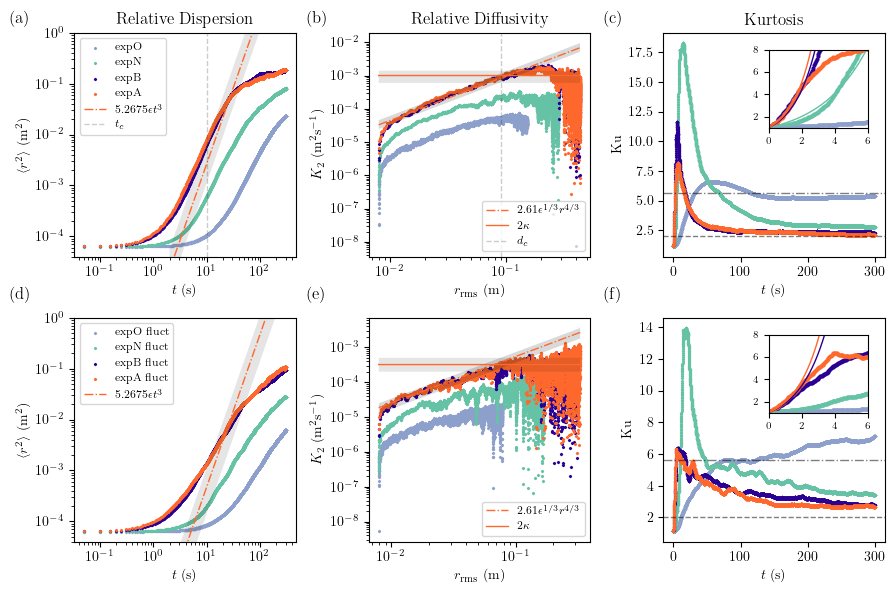

In [78]:
# -------------------------
# Figure (2 rows × 3 cols)
# -------------------------
fig, axes = plt.subplots(2, 3, figsize=(9, 6))

# -------------------------
# Plotting
# -------------------------

for i, (r2, K2, Ku, rtmp, label, c) in enumerate(
        zip(r2_list[::-1], K2_list[::-1], Ku_list[::-1], rtmp_list[::-1], exp_labels[::-1], colors[::-1])):

    # Row index: 0 = mean, 1 = fluct
    row = 0 if i > 3 else 1

    # --- Dispersion ---
    axes[row, 0].scatter(r2.rtime, r2.values, marker='x', s=2, color=c, label=label)
    # --- Diffusivity ---
    axes[row, 1].scatter(rtmp, K2.values, marker='x', s=2, color=c)
    # --- Kurtosis ---
    axes[row, 2].scatter(Ku.rtime, Ku.values,marker='x', s=2, color=c)

    # Extract parameters for THIS experiment and plot fit
    if label == "expA" or label == "expA fluct":
        beta     = betaall[8-i]
        betamin  = betaminall[8-i]
        betamax  = betamaxall[8-i]
        kappal     = kappalall[8-i]
        kappalmin  = kappalminall[8-i]
        kappalmax  = kappalmaxall[8-i]
        T = Tall[i]


        t = r2.rtime[40:]

        # --- Dispersion fit ---
        axes[row,0].fill_between(
            t,
            5.2675*(betamin)**3*t**3,
            5.2675*(betamax)**3*t**3,
            color='k', alpha=0.1,  edgecolor=None
        )

        axes[row,0].plot(
            t,
            5.2675*(beta)**3*t**3, linestyle='-.',
            color="#ff682c", linewidth=1,
            label=r'$5.2675 \epsilon t^3$'
        )


        # --- Diffusivity fit ---
        axes[row,1].fill_between(
            rtmp,
            2.61*betamin*rtmp**(4/3),
            2.61*betamax*rtmp**(4/3), 
            color='k', alpha=0.15, edgecolor=None
        )

        axes[row,1].fill_between(
            rtmp,
            rtmp*0 + 2*kappalmin,
            rtmp*0 + 2*kappalmax,
            color='k', alpha=0.1, edgecolor=None
        )

        axes[row,1].plot(
            rtmp,
            2.61*beta*rtmp**(4/3),
            color="#ff682c", linewidth=1, linestyle='-.',
            label=r'$2.61 \epsilon^{1/3} r^{4/3}$'
        )

        axes[row,1].plot(
            rtmp,
            rtmp*0 + 2*kappal,
            color="#ff682c", linewidth=1,
            label=r'$2\kappa$'
        )


# -------------------------
# Axis formatting
# -------------------------
for row in range(2):
    axes[row, 0].set_xscale('log')
    axes[row, 0].set_yscale('log')
    axes[row, 1].set_xscale('log')
    axes[row, 1].set_yscale('log')

axes[0,0].set_ylim([4e-5,1])
axes[1,0].set_ylim([4e-5,1])


# Labels
axes[0, 0].set_ylabel(r"$\langle r^2 \rangle$ (m$^2$)")
axes[1, 0].set_ylabel(r"$\langle r^2 \rangle$ (m$^2$)")
axes[0, 0].set_xlabel(r"$t$ (s)")
axes[1, 0].set_xlabel(r"$t$ (s)")
axes[0, 1].set_xlabel(r"$r_{\rm rms}$ (m)")
axes[1, 1].set_xlabel(r"$r_{\rm rms}$ (m)")
axes[0, 1].set_ylabel(r"$K_2$ (m$^2$s$^{-1}$)")
axes[1, 1].set_ylabel(r"$K_2$ (m$^2$s$^{-1}$)")
axes[0, 2].set_xlabel(r"$t$ (s)")
axes[1, 2].set_ylabel("Ku")
axes[1, 2].set_xlabel(r"$t$ (s)")
axes[0, 2].set_ylabel("Ku")


axes[0, 0].set_title("Relative Dispersion")
axes[0, 1].set_title("Relative Diffusivity")
axes[0, 2].set_title("Kurtosis")

# Reference lines (both rows)
for row in range(2):
    axes[row, 2].axhline(2, linestyle='--', color='k',alpha=0.5, linewidth=1)
    axes[row, 2].axhline(5.6, linestyle='-.', color='k',alpha=0.5, linewidth=1)
# Vertical line for correlation time and distance
axes[0, 0].axvline(10, linestyle='--', color='k',alpha=0.2, linewidth=1,label=r'$t_c$')
axes[0, 1].axvline(0.09, linestyle='--', color='k',alpha=0.2, linewidth=1,label=r'$d_c$')


# Legends (only once per row)
axes[0, 0].legend(fontsize=8, loc='upper left')
axes[1, 0].legend(fontsize=8, loc='upper left')
axes[0, 1].legend(fontsize=8, loc='lower right')
axes[1, 1].legend(fontsize=8, loc='lower right')


# -------------------------
# Add insets on Kurtosis plots
# -------------------------
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# Top row (mean)
axins_top = inset_axes(axes[0, 2], width="45%", height="35%",
                       loc='upper right', borderpad=1.2)
# Bottom row (fluct)
axins_bot = inset_axes(axes[1, 2], width="45%", height="35%",
                       loc='upper right', borderpad=1.2)

for i, (Ku, label, c, T) in enumerate(zip(Ku_list[::-1], exp_labels[::-1], colors[::-1], Tall[::-1])):

    mask = Ku.rtime <= T

    if 'fluct' not in label:
        # --- TOP inset (mean) ---
        axins_top.scatter(Ku.rtime[mask], Ku.values[mask],
                          s=4, color=c)
        axins_top.plot(Ku.rtime[mask],
                       np.exp(8 * Ku.rtime[mask] / T),
                       color=c, linewidth=1.0)

    else:
        # --- BOTTOM inset (fluct) ---
        axins_bot.scatter(Ku.rtime[mask], Ku.values[mask],
                          s=4, color=c)
        axins_bot.plot(Ku.rtime[mask],
                       np.exp(8 * Ku.rtime[mask] / T),
                       color=c, linewidth=1.0)

# Top inset limits (mean)
axins_top.set_xlim(0, 6)
axins_top.set_ylim(1, 8)

# Bottom inset limits (fluct)
axins_bot.set_xlim(0, 6)
axins_bot.set_ylim(1, 8)

# Optional: smaller ticks
axins_top.tick_params(labelsize=7)
axins_bot.tick_params(labelsize=7)    

# -------------------------
# Panel labels
# -------------------------
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
positions = [
    (0.01, 0.98), (0.34, 0.98), (0.67, 0.98),
    (0.01, 0.52), (0.34, 0.52), (0.67, 0.52)
]

for label, (x, y) in zip(panel_labels, positions):
    fig.text(x, y, label,
             ha='left', va='top',
             fontsize=12, fontstyle='italic')


# -------------------------
# Layout
# -------------------------
plt.tight_layout()

if save:
    output_path = "../paper_RSTA25_Lemasquerier/output_figures/statistics-allexpes.pdf"
    fig.savefig(output_path, format='pdf', bbox_inches='tight')


plt.show()